---
authors:
  - name: Christopher Lance
  - name: Laura Martens
  - name: Lukas Heumos
    roles:
      - writing – review & editing
  - name: Anna Schaar
    roles:
      - writing – review & editing
---


(chromatin-accessibility-quality-control)=
# Quality control

(chromatin-accessibility-quality-control-key-takeaway-1)=
## Motivation

scATAC-seq data are even sparser than scRNA-seq data, since only 1-10% of the open chromatin regions of a cell are detected {cite:p}`atacqc:chen_assessment_2019`.
Nuclei with few fragments or a poor signal-to-noise ratio therefore add little information, and doublets create profiles that do not exist.
Quality control starts from the fragment file, which records every fragment that the Tn5 transposase cut out of accessible chromatin in each cell, and all metrics in this chapter are computed from it.

## Dataset

We use about 10,000 peripheral blood mononuclear cells (PBMCs) measured with the 10x Multiome assay, which profiles gene expression and chromatin accessibility in the same nuclei.
Cell Ranger ARC aligned the reads, called cells and wrote the fragment file, and we analyse the chromatin accessibility of these cells with SnapATAC2 {cite:p}`atacqc:zhang2024snapatac2`.
The gene expression is used later for [gene regulatory networks](gene_regulatory_networks_atac.ipynb).

In [1]:
import logging

import lamindb as ln
import snapatac2 as snap

for name in ("kaleido", "choreographer"):
    logging.getLogger(name).setLevel(logging.WARNING)

ln.connect("theislab/sc-best-practices")

ln.track("IDZANgLhhyWN")

→ connected lamindb: theislab/sc-best-practices


→ loaded Transform('IDZANgLhhyWN0000', key='quality_control.ipynb'), started new Run('d0QqfYHNmP2NZGbA') at 2026-09-29 14:35:58 UTC


→ notebook imports: lamindb-core==2.10.0 snapatac2==2.10.0


We load the cells called by Cell Ranger ARC, their fragment file and the gene annotation of the reference genome from lamindb.

In [2]:
mdata = ln.Artifact.get(
    key="introduction/advanced_data_structures_and_frameworks_muon.h5mu"
).load()
fragments = ln.Artifact.get(
    key="introduction/advanced_data_structures_and_frameworks_atac_fragments.tsv.gz"
).cache()
annotation = ln.Artifact.get(
    key="chromatin_accessibility/gencode_v41_GRCh38.gff3.gz"
).cache()

SnapATAC2 reads the fragments of the called cells into an AnnData object and keeps them in `.obsm`, so that later steps can count them over any set of genomic regions.

In [3]:
adata = snap.pp.import_fragments(
    fragments,
    chrom_sizes=snap.genome.hg38.chrom_sizes,
    whitelist=mdata["atac"].obs_names.tolist(),
    sorted_by_barcode=False,
)
adata

AnnData object with n_obs × n_vars = 11874 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

(chromatin-accessibility-quality-control-key-takeaway-2)=
## Quality metrics

### Fragment size distribution

Tn5 cuts between nucleosomes, so fragment sizes cluster into a nucleosome-free peak below 147 bp and peaks for fragments spanning one or more nucleosomes at multiples of about 200 bp.
A clear periodic pattern indicates that the nuclei were intact and the transposition worked.

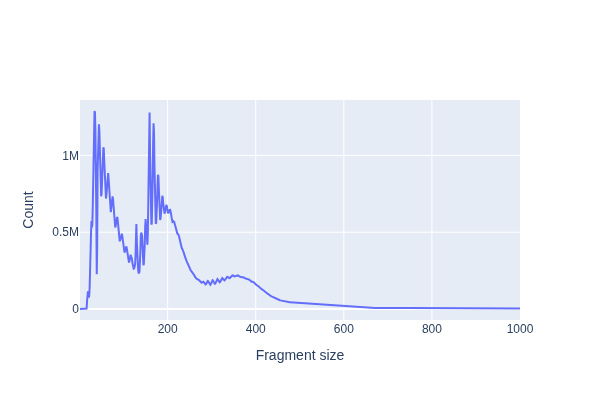

In [4]:
snap.metrics.frag_size_distr(adata)
snap.pl.frag_size_distr(adata, interactive=False)

### TSS enrichment

Transcription start sites (TSSs) of active genes are among the most accessible regions of the genome.
The TSS enrichment score compares the fragments at TSSs with those in their flanks and measures the signal-to-noise ratio of each cell.
It correlates strongly with the fraction of fragments in peaks and can therefore be used before any peaks are called {cite:p}`atacqc:derop2024`.
Its absolute value depends on the set of TSSs and on the tool, so thresholds from other pipelines do not transfer directly.

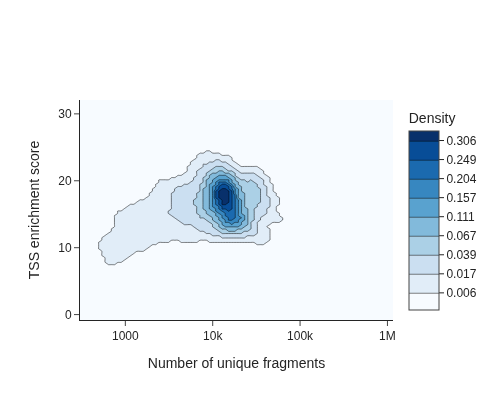

In [5]:
snap.metrics.tsse(adata, annotation)
snap.pl.tsse(adata, interactive=False)

## Filtering cells

The number of fragments and the TSS enrichment are the most informative quality metrics, and the number of fragments also predicts how well doublet detection and annotation work downstream {cite:p}`atacqc:derop2024`.
There are no universal thresholds, since both depend on the protocol and the sequencing depth, so we choose them from the joint distribution above.
We keep cells with 5,000 to 100,000 fragments and a TSS enrichment of at least 10, which removes the low-quality cells in the lower left of the plot and cells with unusually many fragments.

In [6]:
snap.pp.filter_cells(adata, min_counts=5000, max_counts=100000, min_tsse=10)
adata

AnnData object with n_obs × n_vars = 10255 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

(chromatin-accessibility-quality-control-key-takeaway-3)=
## Doublet detection

SnapATAC2 detects doublets like Scrublet {cite:p}`atacqc:wolock2019scrublet`: it simulates doublets by combining random pairs of cells and scores every cell by the fraction of simulated doublets among its neighbors.
This requires a cell-by-feature matrix, for which we count fragments in 500 bp tiles across the genome and select the most informative tiles, as explained in the [next chapter](dimensionality_reduction_clustering.ipynb).
Simulated doublets only resemble doublets of different cell types, which AMULET complements by counting genomic positions covered by more than two fragments, which is impossible in a single diploid nucleus {cite:p}`atacqc:thibodeau2021amulet`.
Combining both approaches detects doublets most reliably {cite:p}`atacqc:germain2022scdblfinder`, and for multiome data, doublets can also be detected in the gene expression.

In [7]:
snap.pp.add_tile_matrix(adata)
snap.pp.select_features(adata, n_features=250000)
snap.pp.scrublet(adata)
snap.pp.filter_doublets(adata)
adata

2026-09-29 16:39:52 - INFO - Selected 250000 features.


2026-09-29 16:39:54 - INFO - Simulating doublets...


2026-09-29 16:39:55 - INFO - Spectral embedding ...


2026-09-29 16:41:11 - INFO - Calculating doublet scores...


2026-09-29 16:41:15 - INFO - Detected doublet rate = 9.751%


AnnData object with n_obs × n_vars = 9255 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'
    layers: None (.X)

We store the filtered cells, their fragments and the tile matrix for the next chapters.

In [8]:
ln.Artifact.from_anndata(
    adata,
    key="chromatin_accessibility/pbmc10k_quality_control.h5ad",
    description="PBMC 10k multiome chromatin accessibility after quality control",
).save()

→ returning artifact with same hash: Artifact(uid='vjLsMVvt3HDiKri00000', key='chromatin_accessibility/pbmc10k_quality_control.h5ad', description='PBMC 10k multiome chromatin accessibility after quality control', suffix='.h5ad', kind='dataset', otype='AnnData', size=3261630727, hash='19FCxRDmDoMxNJMlRHyJ_L', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=162, schema_id=None, created_by_id=2, created_at=2026-09-29 14:32:49 UTC, is_locked=False, version_tag=None, is_latest=True); to track this artifact as an input, use: ln.Artifact.get()


Artifact(uid='vjLsMVvt3HDiKri00000', key='chromatin_accessibility/pbmc10k_quality_control.h5ad', description='PBMC 10k multiome chromatin accessibility after quality control', suffix='.h5ad', kind='dataset', otype='AnnData', size=3261630727, hash='19FCxRDmDoMxNJMlRHyJ_L', n_files=None, n_observations=9255, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=162, schema_id=None, created_by_id=2, created_at=2026-09-29 14:32:49 UTC, is_locked=False, version_tag=None, is_latest=True)

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Christopher Lance
* Laura Martens

### Reviewers

* Lukas Heumos
* Anna Schaar